<a href="https://colab.research.google.com/github/Carolaynebarret/DataConnect/blob/main/Mini_Desafio_DataConnec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. INTRODUÇÃO



In [261]:
from google.colab import drive
drive.mount('/gdrive')

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


## 2. IMPORTAÇÕES

Para começar, vamos importar todas as bibliotecas Python necessárias para o diagnóstico.

In [262]:
import pandas as pd
import numpy as np
import re # Para expressões regulares, especialmente na análise de datas
from IPython.display import display # Para exibir DataFrames de forma formatada

In [263]:
import matplotlib.pyplot as plt
import seaborn as sns


## 3. CONFIGURAÇÃO E CARREGAMENTO

Nesta seção, definimos os caminhos para os arquivos CSV e carregamos cada um deles em DataFrames do Pandas. É importante garantir que os arquivos estejam na localização esperada.

In [264]:
file_paths = {
    'apontamentos': '/gdrive/MyDrive/dados-dataconnect/dc_apontamentos.csv',
    'projetos': '/gdrive/MyDrive/dados-dataconnect/dc_projetos.csv',
    'clientes': '/gdrive/MyDrive/dados-dataconnect/dc_clientes.csv',
    'analistas': '/gdrive/MyDrive/dados-dataconnect/dc_analistas.csv',
    'satisfacao': '/gdrive/MyDrive/dados-dataconnect/dc_satisfacao.csv',
}

dfs = {}

print("Carregando arquivos CSV...")
for name, path in file_paths.items():
    try:
        dfs[name] = pd.read_csv(path)
        print(f"  Arquivo '{name}.csv' carregado com sucesso!")
    except FileNotFoundError:
        print(f"  ERRO: Arquivo '{name}.csv' não encontrado em '{path}'. Verifique o caminho ou se ele foi carregado corretamente.")
    except Exception as e:
        print(f"  ERRO ao carregar o arquivo '{name}.csv': {e}")

Carregando arquivos CSV...
  Arquivo 'apontamentos.csv' carregado com sucesso!
  Arquivo 'projetos.csv' carregado com sucesso!
  Arquivo 'clientes.csv' carregado com sucesso!
  Arquivo 'analistas.csv' carregado com sucesso!
  Arquivo 'satisfacao.csv' carregado com sucesso!


## 4. CONFIGURAÇÕES DO DIAGNÓSTICO

Aqui, definimos as configurações essenciais para o diagnóstico, como as chaves primárias de cada tabela e as colunas que devem ser tratadas como datas. Essas configurações são cruciais para um diagnóstico preciso.

In [265]:
primary_keys_map = {
    'projetos': 'projeto_id',
    'apontamentos': 'apontamento_id',
    'clientes': 'cliente_id',
    'analistas': 'analista_id',
    'satisfacao': 'pesquisa_id',
}

date_columns_map = {
    'projetos': ['data_inicio', 'data_fim_prevista', 'data_fim_real'],
    'apontamentos': ['data'],
    'clientes': ['data_cadastro'],
    'analistas': ['data_admissao'],
    'satisfacao': ['data_pesquisa']
}




### 4.1 Funções Auxiliares de Diagnóstico

Para manter o código organizado e reutilizável, definimos algumas funções auxiliares que serão usadas para realizar os diferentes tipos de análises em cada DataFrame. Isso evita repetição de código e torna o diagnóstico mais fácil de entender e manter.

### 4.1.1 Função `analyze_structure`

Esta função analisa a estrutura de um DataFrame, exibindo o número de linhas e colunas, além dos nomes das colunas.

In [266]:
def analyze_structure(df_name, df):
    print(f"  **Estrutura da tabela '{df_name}'**")
    print(f"  - Dimensões do DataFrame (linhas, colunas):")
    display(df.shape)
    print(f"  - Nomes das colunas:")
    display(pd.Series(df.columns))

### 4.1.2 Função `display_head`

Esta função exibe as primeiras `num_rows` de um DataFrame para uma visualização rápida do conteúdo.

In [267]:
def display_head(df_name, df, num_rows=10):
    print(f"  **Primeiras {num_rows} linhas da tabela '{df_name}'**")
    display(df.head(num_rows))

### 4.1.3 Função `analyze_dtypes`

Esta função verifica os tipos de dados de cada coluna no DataFrame e exibe um resumo detalhado, incluindo o output de `df.info()` e `df.dtypes`.

In [268]:
def analyze_dtypes(df_name, df):
    print(f"  **Tipos de dados da tabela '{df_name}'**")
    print("  - Informações detalhadas (`df.info()`):")
    df.info()
    print("  - Tipos de dados das colunas (`df.dtypes`):")
    display(df.dtypes)

### 4.1.4 Função `analyze_nulls`

Esta função identifica e exibe as colunas com valores nulos e suas respectivas contagens.

In [269]:
def analyze_nulls(df_name, df):
    print(f"  **Valores Nulos na tabela '{df_name}'**")
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print("    Colunas com valores nulos (e suas contagens):")
        display(null_counts[null_counts > 0])
    else:
        print("    Não há valores nulos em nenhuma coluna.")

### 4.1.5 Função `analyze_duplicates`

Esta função verifica a presença de linhas duplicadas, tanto completas quanto pela chave primária especificada.

In [270]:
def analyze_duplicates(df_name, df, pk_map):
    print(f"  **Análise de Duplicatas na tabela '{df_name}'**")
    full_duplicates = df.duplicated().sum()
    print(f"    - Linhas duplicadas completas: {full_duplicates}")

    pk = pk_map.get(df_name)
    if pk and pk in df.columns:
        pk_duplicates = df.duplicated(subset=[pk]).sum()
        print(f"    - Duplicatas pela chave primária '{pk}': {pk_duplicates}")
        if pk_duplicates > 0:
            print(f"      Registros duplicados pela chave '{pk}' (exemplos):")
            display(df[df.duplicated(subset=[pk], keep=False)].sort_values(by=pk).head()) # Usando .head() para exemplos
    else:
        print(f"    AVISO: Chave primária '{pk}' não definida ou não encontrada para '{df_name}'. Não foi possível verificar duplicatas por chave.")

### 4.1.6 Função `analyze_categorical_text`

Esta função examina colunas de tipo 'object' (categóricas/texto) para identificar valores únicos e a presença de espaços em branco indesejados.

In [271]:
def analyze_categorical_text(df_name, df, pk_map):
    print(f"  **Análise de Colunas Categóricas/Texto na tabela '{df_name}'**")
    object_cols = df.select_dtypes(include='object').columns

    if object_cols.empty:
        print("    Não há colunas do tipo 'object' para analisar.")
    else:
        for col in object_cols:
            # Ignorar colunas que são PKs ou serão tratadas especificamente como numéricas (horas, valor_contrato)
            if col == pk_map.get(df_name) or \
               (df_name == 'apontamentos' and col == 'horas') or \
               (df_name == 'projetos' and col == 'valor_contrato'):
                continue

            print(f"    - Coluna '{col}':")
            unique_vals = df[col].astype(str).unique()
            if len(unique_vals) <= 50: # Mostrar valores únicos se não forem muitos
                print(f"      Valores únicos ({len(unique_vals)}):")
                display(pd.Series(unique_vals).sort_values().reset_index(drop=True))
            else:
                print(f"      {len(unique_vals)} valores únicos (mostrando os 5 primeiros):")
                display(pd.Series(unique_vals[:5]))

            # Verificar espaços em branco no início/fim
            has_leading_trailing_spaces = df[col].astype(str).apply(lambda x: x != x.strip()).any()
            if has_leading_trailing_spaces:
                example_value = df[col][df[col].astype(str).apply(lambda x: x != x.strip())].dropna().iloc[0]
                print(f"      AVISO: Existem valores com espaços no início ou fim. Exemplo: '{example_value}'")
            else:
                print("      Não foram encontrados valores com espaços no início ou fim.")

### 4.1.7 Função `analyze_dates`

Esta função analisa colunas de data específicas, identificando formatos, valores ambíguos (que podem ser interpretados de múltiplas formas) e datas inválidas ou não parseáveis.

In [272]:
def analyze_dates(df_name, df, date_cols_map):
    print(f"  **Análise de Colunas de Data na tabela '{df_name}'**")
    specific_date_cols = date_cols_map.get(df_name, [])

    if not specific_date_cols:
        print("    Nenhuma coluna de data específica para análise nesta tabela.")
    else:
        for col in specific_date_cols:
            if col not in df.columns:
                print(f"    AVISO: Coluna de data '{col}' especificada para '{df_name}' não encontrada no DataFrame.")
                continue

            print(f"    - Coluna '{col}':")
            print(f"      Total de valores: {df[col].count()}")
            print(f"      Valores nulos: {df[col].isnull().sum()}")

            identified_formats = {}
            invalid_values = []
            ambiguous_values = []

            pt_month_to_en = {
                'jan': 'Jan', 'fev': 'Feb', 'mar': 'Mar', 'abr': 'Apr',
                'mai': 'May', 'jun': 'Jun', 'jul': 'Jul', 'ago': 'Aug',
                'set': 'Sep', 'out': 'Oct', 'nov': 'Nov', 'dez': 'Dec'
            }
            dd_mmm_yyyy_pattern = re.compile(r'^(\d{2})-([a-zA-Z]{3})-(\d{4})$', re.IGNORECASE)

            explicit_formats_list = [
                ('%Y-%m-%d', '%Y-%m-%d'), # YYYY-MM-DD
                ('%d/%m/%Y', '%d/%m/%Y'), # DD/MM/YYYY
                ('%m/%d/%Y', '%m/%d/%Y'), # MM/DD/YYYY
            ]
            pt_br_month_format_key = 'DD-mmm-YYYY (Meses PT-BR)'

            for val in df[col].dropna().unique():
                val_str = str(val)
                found_specific_format = False

                match = dd_mmm_yyyy_pattern.match(val_str)
                if match:
                    day_part = match.group(1)
                    month_abbr_pt = match.group(2).lower()
                    year_part = match.group(3)

                    if month_abbr_pt in pt_month_to_en:
                        val_str_for_pt_parse = f"{day_part}-{pt_month_to_en[month_abbr_pt]}-{year_part}"
                        if pd.to_datetime(val_str_for_pt_parse, format='%d-%b-%Y', errors='coerce') is not pd.NaT:
                            if pt_br_month_format_key not in identified_formats:
                                identified_formats[pt_br_month_format_key] = []
                            if val_str not in identified_formats[pt_br_month_format_key]:
                                identified_formats[pt_br_month_format_key].append(val_str)
                            found_specific_format = True

                if not found_specific_format:
                    for fmt_key_output, fmt_parsing in explicit_formats_list:
                        if pd.to_datetime(val_str, format=fmt_parsing, errors='coerce') is not pd.NaT:
                            if fmt_key_output not in identified_formats:
                                identified_formats[fmt_key_output] = []
                            if val_str not in identified_formats[fmt_key_output]:
                                identified_formats[fmt_key_output].append(val_str)
                            found_specific_format = True
                            break

                if not found_specific_format:
                    try:
                        pd.to_datetime(val_str, errors='raise')
                        if 'Outro formato válido (inferido)' not in identified_formats:
                            identified_formats['Outro formato válido (inferido)'] = []
                        if val_str not in identified_formats['Outro formato válido (inferido)']:
                            identified_formats['Outro formato válido (inferido)'].append(val_str)
                    except (ValueError, TypeError):
                        if val_str not in invalid_values:
                            invalid_values.append(val_str)

                if '/' in val_str:
                    try_dm_y = pd.to_datetime(val_str, format='%d/%m/%Y', errors='coerce') is not pd.NaT
                    try_md_y = pd.to_datetime(val_str, format='%m/%d/%Y', errors='coerce') is not pd.NaT

                    parts = val_str.split('/')
                    if len(parts) == 3:
                        try:
                            day_part_val = int(parts[0])
                            month_part_val = int(parts[1])
                            if try_dm_y and try_md_y and day_part_val <= 12 and month_part_val <= 12:
                                if val_str not in ambiguous_values:
                                    ambiguous_values.append(val_str)
                        except ValueError:
                            pass

            print("      Padrões de representação encontrados (e exemplos):")
            if not identified_formats:
                print("        Nenhum padrão de data reconhecido.")
            else:
                for fmt, examples in identified_formats.items():
                    print(f"        - '{fmt}': {len(examples)} ocorrências. Exemplos:")
                    display(pd.Series(examples[:5]))

            print("      Datas ambíguas (DD/MM/YYYY ou MM/DD/YYYY):")
            if ambiguous_values:
                print(f"        {len(ambiguous_values)} valores ambíguos. Exemplos:")
                display(pd.Series(ambiguous_values[:5]))
            else:
                print("        Nenhuma data ambígua encontrada.")

            print("      Datas claramente inválidas ou impossíveis:")
            if invalid_values:
                print(f"        {len(invalid_values)} valores inválidos. Exemplos:")
                display(pd.Series(invalid_values[:5]))
            else:
                print("        Nenhuma data claramente inválida encontrada.")

### 4.1.8 Função `analyze_horas`

Esta função é específica para a coluna 'horas' na tabela de apontamentos, verificando formatos numéricos, horas negativas e valores acima de 24.

In [273]:
def analyze_horas(df):
    print("  **Análise da coluna 'horas'**")
    horas_aux = df['horas'].astype(str).str.replace(',', '.', regex=False)
    horas_numeric_analysis = pd.to_numeric(horas_aux, errors='coerce')

    print("    - Contagem de ocorrências dos valores originais de 'horas':")
    display(df['horas'].value_counts(dropna=False).sort_index())

    negative_horas_idx = horas_numeric_analysis[horas_numeric_analysis < 0].index
    if not negative_horas_idx.empty:
        print(f"    Existem {len(negative_horas_idx)} apontamentos com horas negativas (`horas` < 0). Exemplos:")
        display(df.loc[negative_horas_idx].head())
    else:
        print("    Nenhum apontamento com horas negativas.")

    outliers_gt_24_idx = horas_numeric_analysis[horas_numeric_analysis > 24].index
    if not outliers_gt_24_idx.empty:
        print(f"    Existem {len(outliers_gt_24_idx)} apontamentos com mais de 24 horas (`horas` > 24). Exemplos:")
        display(df.loc[outliers_gt_24_idx].head())
    else:
        print("    Nenhum apontamento com mais de 24 horas.")

    invalid_horas_conversion_idx = horas_numeric_analysis[horas_numeric_analysis.isna() & df['horas'].notna()].index
    if not invalid_horas_conversion_idx.empty:
        print(f"    Existem {len(invalid_horas_conversion_idx)} valores em 'horas' que não puderam ser convertidos para numérico. Exemplos:")
        display(df.loc[invalid_horas_conversion_idx].head())
    else:
        print("    Todos os valores não nulos em 'horas' puderam ser convertidos para numérico.")

### 4.1.9 Função `analyze_valor_contrato`

Esta função é específica para a coluna 'valor_contrato' na tabela de projetos, verificando formatos numéricos e possíveis outliers.

In [274]:
def analyze_valor_contrato(df):
    print("  **Análise da coluna 'valor_contrato'**")
    valor_contrato_aux = df['valor_contrato'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    valor_contrato_numeric_analysis = pd.to_numeric(valor_contrato_aux, errors='coerce')

    print("    - Contagem de ocorrências dos valores originais de 'valor_contrato':")
    display(df['valor_contrato'].value_counts(dropna=False).sort_index())

    valor_contrato_valid_for_analysis = valor_contrato_numeric_analysis.dropna()

    if not valor_contrato_valid_for_analysis.empty:
        print("    - Estatísticas descritivas (série numérica auxiliar para análise):")
        display(valor_contrato_valid_for_analysis.describe())

        Q1 = valor_contrato_valid_for_analysis.quantile(0.25)
        Q3 = valor_contrato_valid_for_analysis.quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR

        outliers_contrato_idx = valor_contrato_numeric_analysis[
            (valor_contrato_numeric_analysis < lower_bound) |
            (valor_contrato_numeric_analysis > upper_bound)
        ].index

        if not outliers_contrato_idx.empty:
            print(f"    Existem {len(outliers_contrato_idx)} projetos com `valor_contrato` fora dos limites IQR (possíveis outliers). Exemplos:")
            display(df.loc[outliers_contrato_idx].head())
        else:
            print("    Nenhuma anomalia de `valor_contrato` detectada pelo método IQR simples.")
    else:
        print("    Não há valores numéricos válidos para análise estatística ou de outliers.")

    invalid_valor_contrato_conversion_idx = valor_contrato_numeric_analysis[valor_contrato_numeric_analysis.isna() & df['valor_contrato'].notna()].index
    if not invalid_valor_contrato_conversion_idx.empty:
        print(f"    Existem {len(invalid_valor_contrato_conversion_idx)} valores em 'valor_contrato' que não puderam ser convertidos para numérico. Exemplos:")
        display(df.loc[invalid_valor_contrato_conversion_idx].head())
    else:
        print("    Todos os valores não nulos em 'valor_contrato' puderam ser convertidos para numérico.")

### 4.1.10 Função `analyze_costo_hora`

Esta função verifica a distribuição da coluna 'custo_hora' na tabela de analistas, identificando valores negativos ou anômalos.

In [275]:
def analyze_costo_hora(df):
    print("  **Análise da coluna 'custo_hora'**")
    numeric_costo_hora = pd.to_numeric(df['custo_hora'], errors='coerce')
    if not numeric_costo_hora.dropna().empty:
        print("    - Estatísticas descritivas:")
        display(numeric_costo_hora.describe())
        negative_costs_idx = numeric_costo_hora[numeric_costo_hora < 0].index
        if not negative_costs_idx.empty:
            print(f"    Existem {len(negative_costs_idx)} analistas com 'custo_hora' negativo. Exemplos:")
            display(df.loc[negative_costs_idx].head())
    else:
        print("    Não há valores numéricos válidos em 'custo_hora' para análise.")

### 4.1.11 Função `analyze_nota_nps`

Esta função analisa a coluna 'nota_nps' na tabela de satisfação, verificando a distribuição e notas fora do intervalo esperado de 0 a 10.

In [276]:
def analyze_nota_nps(df):
    print("  **Análise da coluna 'nota_nps'**")
    numeric_nota_nps = pd.to_numeric(df['nota_nps'], errors='coerce')
    if not numeric_nota_nps.dropna().empty:
        print("    - Estatísticas descritivas:")
        display(numeric_nota_nps.describe())
        invalid_range_idx = numeric_nota_nps[(numeric_nota_nps < 0) | (numeric_nota_nps > 10)].index
        if not invalid_range_idx.empty:
            print(f"    Existem {len(invalid_range_idx)} pesquisas com 'nota_nps' fora do intervalo 0-10. Exemplos:")
            display(df.loc[invalid_range_idx].head())
    else:
        print("    Não há valores numéricos válidos em 'nota_nps' para análise.")

### 4.1.12 Função `print_summary`

Esta função imprime um resumo conciso dos principais achados para um DataFrame específico, direcionando o usuário para as saídas detalhadas.

In [277]:
def print_summary(df_name):
    print(f"\n  --- Resumo do Diagnóstico para: {df_name.upper()} ---")
    print("  (Revise as saídas acima para detalhes dos problemas encontrados.)")

### 4.1.13 Função `check_foreign_key`

Esta função auxiliar verifica a consistência de chaves estrangeiras entre dois DataFrames, identificando IDs na tabela de origem que não possuem correspondência na tabela de destino.

In [278]:
def check_foreign_key(source_df_name, source_col, target_df_name, target_col, dfs):
    if source_df_name in dfs and target_df_name in dfs and source_col in dfs[source_df_name].columns and target_col in dfs[target_df_name].columns:
        source_ids = dfs[source_df_name][source_col].dropna().unique()
        target_ids = dfs[target_df_name][target_col].dropna().unique()
        missing_ids = np.setdiff1d(source_ids, target_ids)
        if len(missing_ids) > 0:
            print(f"  AVISO: {len(missing_ids)} '{source_col}' em `{source_df_name}` não encontrados em `{target_df_name}` (`{target_col}`).")
            print(f"    Exemplos:")
            display(pd.Series(missing_ids[:5])) # Exibe os 5 primeiros IDs ausentes
        else:
            print(f"  Todos os '{source_col}' em `{source_df_name}` existem em `{target_df_name}`.")
    else:
        print(f"  Não foi possível verificar a consistência de '{source_col}' entre `{source_df_name}` e `{target_df_name}` (arquivos/colunas ausentes ou renomeadas).")

# 5. DIAGNÓSTICO

## 5.1 Diagnóstico - `dc_projetos.csv`

### 5.1.1 Estrutura

In [279]:
df_name = 'projetos'
df = dfs[df_name]
print(f"**Iniciando diagnóstico para `{df_name}`...**\n")
analyze_structure(df_name, df)

**Iniciando diagnóstico para `projetos`...**

  **Estrutura da tabela 'projetos'**
  - Dimensões do DataFrame (linhas, colunas):


(141, 11)

  - Nomes das colunas:


,0
0,projeto_id
1,cliente_id
2,nome_projeto
3,tipo_servico
4,squad
5,status
6,data_inicio
7,data_fim_prevista
8,data_fim_real
9,horas_vendidas


### 5.1.2 Primeiras linhas

In [280]:
display_head(df_name, df)

  **Primeiras 10 linhas da tabela 'projetos'**


,projeto_id,cliente_id,nome_projeto,tipo_servico,squad,status,data_inicio,data_fim_prevista,data_fim_real,horas_vendidas,valor_contrato
0,PRJ0001,CLI013,Dashboard BI - Windsor,Dashboard B.I.,Delta,CONCLUÍDO,2024-03-19,2024-05-06,08/05/2024,288,NaN
1,PRJ0002,CLI022,Diagnóstico de Dados - Umbu,Diagnóstico de Dados,Alpha,Cancelado,2024-10-01,2024-10-28,NaN,89,24044.51
2,PRJ0003,CLI051,Pipeline de Dados - Cristal,Pipeline de Dados,Charlie,Concluído,2025-06-16,20/10/2025,10/15/2025,423,91525.58
3,PRJ0004,CLI060,Dashboard BI - Kairós,Dashboard BI,Echo,Concluído,2024-03-19,25-abr-2024,2024-04-26,220,47409.01
4,PRJ0005,CLI020,Modelo Preditivo - Duna,Modelo Preditivo,Echo,Concluído,09/12/2024,02/27/2025,2025-03-12,338,"61.970,49"
5,PRJ0006,CLI048,Pipeline de Dados - Pantanal,Pipeline de Dados,Bravo,Concluído,26-fev-2025,2025-06-16,2025-07-09,515,110285.35
6,PRJ0007,CLI021,Data Warehouse - Quartzo,Data Warehouse,Delta,Concluído,08/13/2024,2025-02-17,2025-02-20,852,169819.61
7,PRJ0008,CLI041,Data Warehouse - Everest,Data Warehouse,Echo,Em andamento,2026-02-16,2026-09-04,NaN,743,133841.27
8,PRJ0009,CLI031,Dashboard BI - Everest,Dashboard BI,Echo,Concluído,2025-10-13,2025-11-17,17-nov-2025,157,"34.835,02"
9,PRJ0010,CLI001,Modelo Preditivo - Umbu,Modelo Preditivo,Alpha,Concluído,2024-07-08,22/10/2024,10/21/2024,578,98986.73


### 5.1.3 Tipos

In [281]:
analyze_dtypes(df_name, df)

  **Tipos de dados da tabela 'projetos'**
  - Informações detalhadas (`df.info()`):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   projeto_id         141 non-null    object
 1   cliente_id         141 non-null    object
 2   nome_projeto       141 non-null    object
 3   tipo_servico       141 non-null    object
 4   squad              141 non-null    object
 5   status             141 non-null    object
 6   data_inicio        141 non-null    object
 7   data_fim_prevista  141 non-null    object
 8   data_fim_real      128 non-null    object
 9   horas_vendidas     141 non-null    int64 
 10  valor_contrato     134 non-null    object
dtypes: int64(1), object(10)
memory usage: 12.2+ KB
  - Tipos de dados das colunas (`df.dtypes`):


,0
projeto_id,object
cliente_id,object
nome_projeto,object
tipo_servico,object
squad,object
status,object
data_inicio,object
data_fim_prevista,object
data_fim_real,object
horas_vendidas,int64


### 5.1.4 Nulos

In [282]:
analyze_nulls(df_name, df)

  **Valores Nulos na tabela 'projetos'**
    Colunas com valores nulos (e suas contagens):


,0
data_fim_real,13
valor_contrato,7


### 5.1.5 Duplicatas

In [283]:
analyze_duplicates(df_name, df, primary_keys_map)

  **Análise de Duplicatas na tabela 'projetos'**
    - Linhas duplicadas completas: 1
    - Duplicatas pela chave primária 'projeto_id': 1
      Registros duplicados pela chave 'projeto_id' (exemplos):


,projeto_id,cliente_id,nome_projeto,tipo_servico,squad,status,data_inicio,data_fim_prevista,data_fim_real,horas_vendidas,valor_contrato
9,PRJ0010,CLI001,Modelo Preditivo - Umbu,Modelo Preditivo,Alpha,Concluído,2024-07-08,22/10/2024,10/21/2024,578,98986.73
140,PRJ0010,CLI001,Modelo Preditivo - Umbu,Modelo Preditivo,Alpha,Concluído,2024-07-08,22/10/2024,10/21/2024,578,98986.73


### 5.1.6 Categorias e textos

In [284]:
analyze_categorical_text(df_name, df, primary_keys_map)

  **Análise de Colunas Categóricas/Texto na tabela 'projetos'**
    - Coluna 'cliente_id':
      54 valores únicos (mostrando os 5 primeiros):


,0
0,CLI013
1,CLI022
2,CLI051
3,CLI060
4,CLI020


      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'nome_projeto':
      87 valores únicos (mostrando os 5 primeiros):


,0
0,Dashboard BI - Windsor
1,Diagnóstico de Dados - Umbu
2,Pipeline de Dados - Cristal
3,Dashboard BI - Kairós
4,Modelo Preditivo - Duna


      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'tipo_servico':
      Valores únicos (20):


...

      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'data_fim_prevista':
      131 valores únicos (mostrando os 5 primeiros):


,0
0,2024-05-06
1,2024-10-28
2,20/10/2025
3,25-abr-2024
4,02/27/2025


      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'data_fim_real':
      118 valores únicos (mostrando os 5 primeiros):


,0
0,08/05/2024
1,nan
2,10/15/2025
3,2024-04-26
4,2025-03-12


      Não foram encontrados valores com espaços no início ou fim.


### 5.1.7 Datas

In [285]:
analyze_dates(df_name, df, date_columns_map)

  **Análise de Colunas de Data na tabela 'projetos'**
    - Coluna 'data_inicio':
      Total de valores: 141
      Valores nulos: 0
      Padrões de representação encontrados (e exemplos):
        - '%Y-%m-%d': 73 ocorrências. Exemplos:


,0
0,2024-03-19
1,2024-10-01
2,2025-06-16
3,2026-02-16
4,2025-10-13


        - '%d/%m/%Y': 30 ocorrências. Exemplos:


,0
0,09/12/2024
1,09/02/2026
2,06/12/2024
3,10/06/2025
4,14/07/2025


        - 'DD-mmm-YYYY (Meses PT-BR)': 20 ocorrências. Exemplos:


...

        - 'DD-mmm-YYYY (Meses PT-BR)': 18 ocorrências. Exemplos:


,0
0,17-nov-2025
1,16-jun-2026
2,08-abr-2026
3,14-out-2024
4,24-jun-2025


      Datas ambíguas (DD/MM/YYYY ou MM/DD/YYYY):
        13 valores ambíguos. Exemplos:


,0
0,08/05/2024
1,01/04/2026
2,12/01/2025
3,11/11/2025
4,11/04/2024


      Datas claramente inválidas ou impossíveis:
        Nenhuma data claramente inválida encontrada.


### 5.1.8 Análise de `valor_contrato`

In [286]:
if 'valor_contrato' in df.columns:
    analyze_valor_contrato(df)
else:
    print("  Columna 'valor_contrato' não encontrada.")

  **Análise da coluna 'valor_contrato'**
    - Contagem de ocorrências dos valores originais de 'valor_contrato':


,count
valor_contrato,
"10.174,16",1
"10.837,13",1
100834.44,1
101146.75,1
"102.409,86",1
...,...
96306.00,1
98617.32,1
98986.73,2


    - Estatísticas descritivas (série numérica auxiliar para análise):


,valor_contrato
count,1.340000e+02
mean,7.963822e+07
std,8.634463e+08
min,1.017416e+04
25%,7.778035e+05
50%,3.820472e+06
75%,8.375490e+06
max,1.000000e+10


    Existem 2 projetos com `valor_contrato` fora dos limites IQR (possíveis outliers). Exemplos:


,projeto_id,cliente_id,nome_projeto,tipo_servico,squad,status,data_inicio,data_fim_prevista,data_fim_real,horas_vendidas,valor_contrato
25,PRJ0026,CLI042,Data Warehouse - Ébano,Data Warehouse,Charlie,Concluído,14/07/2025,01/23/2026,2026-01-26,1030,226034.49
55,PRJ0056,CLI055,Modelo Preditivo - Quartzo,Modelo Preditivo,Charlie,Concluído,01/31/2025,2025-04-30,2025-04-29,525,99999999.00


    Todos os valores não nulos em 'valor_contrato' puderam ser convertidos para numérico.


### 5.1.9 Resumo do `dc_projetos`

#### 5.1.9.1 Distribuição de Status dos Projetos

/tmp/ipykernel_919/2472734456.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_projetos, x='status', palette='viridis', order=df_projetos['status'].value_counts().index)


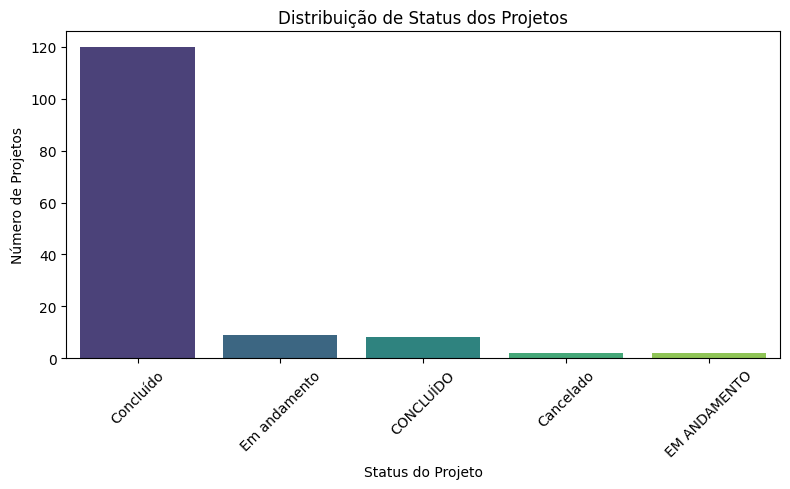

In [287]:
try:
    df_projetos = dfs['projetos']
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_projetos, x='status', palette='viridis', order=df_projetos['status'].value_counts().index)
    plt.title('Distribuição de Status dos Projetos')
    plt.xlabel('Status do Projeto')
    plt.ylabel('Número de Projetos')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
except KeyError:
    print("ERRO: DataFrame 'projetos' não encontrado para gerar o gráfico.")
except Exception as e:
    print(f"Ocorreu um erro ao gerar o gráfico de Status dos Projetos: {e}")

#### 5.1.9.2 Distribuição de Tipo de Serviço dos Projetos

/tmp/ipykernel_919/3843758423.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_projetos, y='tipo_servico', palette='magma', order=df_projetos['tipo_servico'].value_counts().index)


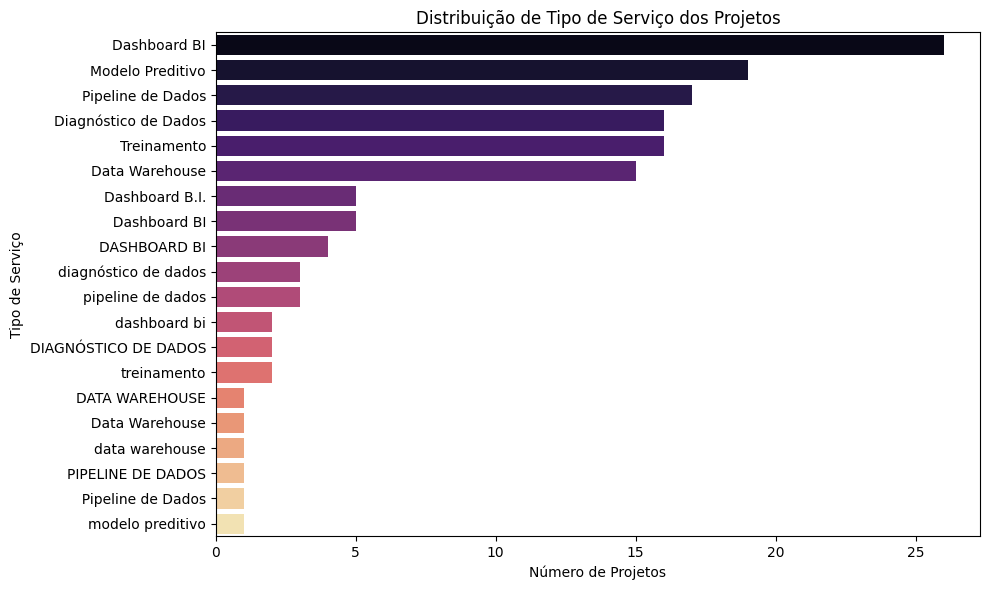

In [288]:
try:
    # Verifica se df_projetos foi definido na célula anterior
    if 'df_projetos' in locals():
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df_projetos, y='tipo_servico', palette='magma', order=df_projetos['tipo_servico'].value_counts().index)
        plt.title('Distribuição de Tipo de Serviço dos Projetos')
        plt.xlabel('Número de Projetos')
        plt.ylabel('Tipo de Serviço')
        plt.tight_layout()
        plt.show()
    else:
        print("AVISO: 'df_projetos' não está definido. Execute a célula anterior ('08e92975') primeiro.")
except Exception as e:
    print(f"Ocorreu um erro ao gerar o gráfico de Tipo de Serviço dos Projetos: {e}")

#### 5.1.9.3 Distribuição de Valores de Contrato

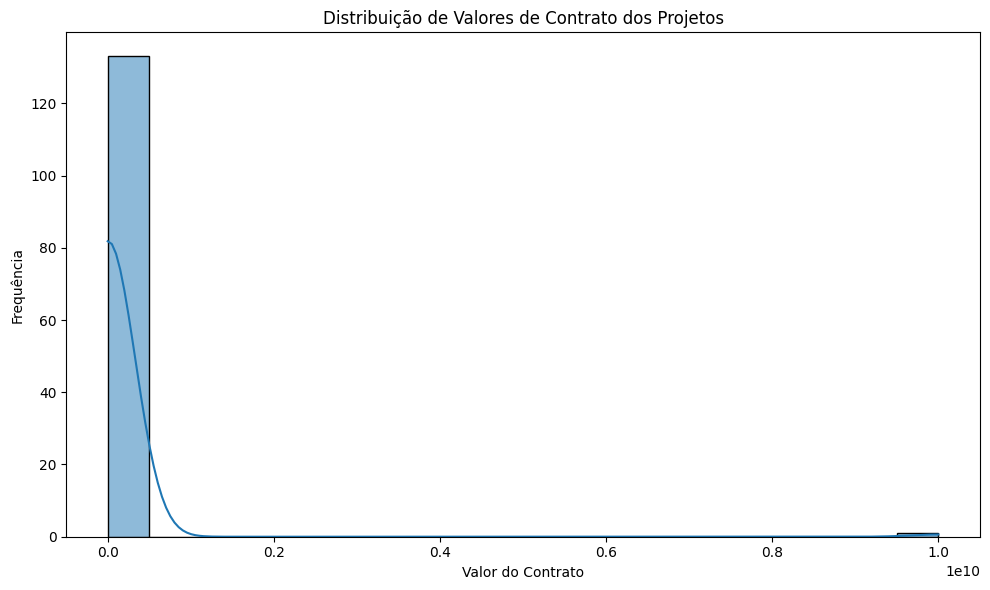

In [289]:
try:
    if 'df_projetos' in locals():
        df_projetos_temp = df_projetos.copy()
        df_projetos_temp['valor_contrato_numeric'] = df_projetos_temp['valor_contrato'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        df_projetos_temp['valor_contrato_numeric'] = pd.to_numeric(df_projetos_temp['valor_contrato_numeric'], errors='coerce')

        plt.figure(figsize=(10, 6))
        sns.histplot(df_projetos_temp['valor_contrato_numeric'].dropna(), kde=True, bins=20)
        plt.title('Distribuição de Valores de Contrato dos Projetos')
        plt.xlabel('Valor do Contrato')
        plt.ylabel('Frequência')
        plt.tight_layout()
        plt.show()
    else:
        print("AVISO: 'df_projetos' não está definido. Execute as células anteriores que o inicializam.")
except Exception as e:
    print(f"Ocorreu um erro ao gerar o gráfico de Valores de Contrato dos Projetos: {e}")

## 5.2 Diagnóstico - `dc_apontamentos.csv`

### 5.2.1 Estrutura

In [290]:
df_name = 'apontamentos'
df = dfs[df_name]
print(f"**Iniciando diagnóstico para `{df_name}`...**\n")
analyze_structure(df_name, df)

**Iniciando diagnóstico para `apontamentos`...**

  **Estrutura da tabela 'apontamentos'**
  - Dimensões do DataFrame (linhas, colunas):


(9879, 6)

  - Nomes das colunas:


,0
0,apontamento_id
1,projeto_id
2,analista_id
3,data
4,horas
5,atividade


### 5.2.2 Primeiras linhas

In [291]:
display_head(df_name, df)

  **Primeiras 10 linhas da tabela 'apontamentos'**


,apontamento_id,projeto_id,analista_id,data,horas,atividade
0,APT002473,PRJ0032,ANL006,2026-03-23,6,Reunião com cliente
1,APT004798,PRJ0064,ANL008,2026-05-08,6.5,Apresentação
2,APT005566,PRJ0079,ANL012,2025-06-02,6,Coleta
3,APT000099,PRJ0003,ANL009,2025-09-15,4.5,Documentação
4,APT009367,PRJ0134,ANL009,2026-01-22,4,Modelagem
5,APT008582,PRJ0121,ANL009,05/04/2026,8,Testes
6,APT006641,PRJ0093,ANL020,11/09/2024,2,Testes
7,APT006423,PRJ0089,ANL022,2024-09-11,4.5,Coleta
8,APT007648,PRJ0109,ANL019,2026-03-27,6,Modelagem
9,APT006902,PRJ0098,ANL018,10/15/2025,7,Apresentação


### 5.2.3 Tipos

In [292]:
analyze_dtypes(df_name, df)

  **Tipos de dados da tabela 'apontamentos'**
  - Informações detalhadas (`df.info()`):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   apontamento_id  9879 non-null   object
 1   projeto_id      9879 non-null   object
 2   analista_id     9879 non-null   object
 3   data            9879 non-null   object
 4   horas           9879 non-null   object
 5   atividade       9879 non-null   object
dtypes: object(6)
memory usage: 463.2+ KB
  - Tipos de dados das colunas (`df.dtypes`):


,0
apontamento_id,object
projeto_id,object
analista_id,object
data,object
horas,object
atividade,object


### 5.2.4 Nulos

In [293]:
analyze_nulls(df_name, df)

  **Valores Nulos na tabela 'apontamentos'**
    Não há valores nulos em nenhuma coluna.


### 5.2.5 Duplicatas

In [294]:
analyze_duplicates(df_name, df, primary_keys_map)

  **Análise de Duplicatas na tabela 'apontamentos'**
    - Linhas duplicadas completas: 80
    - Duplicatas pela chave primária 'apontamento_id': 80
      Registros duplicados pela chave 'apontamento_id' (exemplos):


,apontamento_id,projeto_id,analista_id,data,horas,atividade
1826,APT000001,PRJ0001,ANL004,2024-04-24,2,COLETA
4603,APT000001,PRJ0001,ANL004,2024-04-24,2,COLETA
3391,APT000098,PRJ0003,ANL021,07/14/2025,4,Dashboard
4046,APT000098,PRJ0003,ANL021,07/14/2025,4,Dashboard
3790,APT000195,PRJ0004,ANL011,03-abr-2024,4,Testes


### 5.2.6 Categorias e textos

In [295]:
analyze_categorical_text(df_name, df, primary_keys_map)

  **Análise de Colunas Categóricas/Texto na tabela 'apontamentos'**
    - Coluna 'projeto_id':
      140 valores únicos (mostrando os 5 primeiros):


,0
0,PRJ0032
1,PRJ0064
2,PRJ0079
3,PRJ0003
4,PRJ0134


      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'analista_id':
      Valores únicos (24):


,0
0,ANL001
1,ANL002
2,ANL003
3,ANL004
4,ANL005
5,ANL006
6,ANL007
7,ANL008
8,ANL009
9,ANL010


      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'data':
      2037 valores únicos (mostrando os 5 primeiros):


,0
0,2026-03-23
1,2026-05-08
2,2025-06-02
3,2025-09-15
4,2026-01-22


      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'atividade':
      Valores únicos (15):


,0
0,APRESENTAÇÃO
1,Apresentação
2,COLETA
3,Coleta
4,DASHBOARD
5,DOCUMENTAÇÃO
6,Dashboard
7,Documentação
8,ETL
9,MODELAGEM


      Não foram encontrados valores com espaços no início ou fim.


### 5.2.7 Datas

In [296]:
analyze_dates(df_name, df, date_columns_map)

  **Análise de Colunas de Data na tabela 'apontamentos'**
    - Coluna 'data':
      Total de valores: 9879
      Valores nulos: 0
      Padrões de representação encontrados (e exemplos):
        - '%Y-%m-%d': 635 ocorrências. Exemplos:


,0
0,2026-03-23
1,2026-05-08
2,2025-06-02
3,2025-09-15
4,2026-01-22


        - '%d/%m/%Y': 607 ocorrências. Exemplos:


,0
0,05/04/2026
1,11/09/2024
2,23/08/2024
3,12/11/2024
4,06/04/2026


        - '%m/%d/%Y': 303 ocorrências. Exemplos:


...

        - 'DD-mmm-YYYY (Meses PT-BR)': 492 ocorrências. Exemplos:


,0
0,21-mai-2026
1,13-jun-2025
2,13-nov-2025
3,19-dez-2025
4,08-out-2024


      Datas ambíguas (DD/MM/YYYY ou MM/DD/YYYY):
        292 valores ambíguos. Exemplos:


,0
0,05/04/2026
1,11/09/2024
2,12/11/2024
3,06/04/2026
4,01/04/2026


      Datas claramente inválidas ou impossíveis:
        Nenhuma data claramente inválida encontrada.


### 5.2.8 Análise de `horas`

In [297]:
if 'horas' in df.columns:
    analyze_horas(df)
else:
    print("  Columna 'horas' não encontrada.")

  **Análise da coluna 'horas'**
    - Contagem de ocorrências dos valores originais de 'horas':


,count
horas,
-4.0,6
2,864
"2,5",41
2.5,207
240.0,8
3,764
"3,5",47
3.5,227
4,1667


    Existem 6 apontamentos com horas negativas (`horas` < 0). Exemplos:


,apontamento_id,projeto_id,analista_id,data,horas,atividade
1096,APT006812,PRJ0096,ANL009,2026-04-17,-4.0,ETL
2035,APT005112,PRJ0070,ANL022,2025-07-17,-4.0,Dashboard
2502,APT008512,PRJ0121,ANL009,04/21/2026,-4.0,Apresentação
4293,APT003412,PRJ0042,ANL013,2025-05-09,-4.0,Coleta
4842,APT000012,PRJ0001,ANL010,24/04/2024,-4.0,Apresentação


    Existem 8 apontamentos com mais de 24 horas (`horas` > 24). Exemplos:


,apontamento_id,projeto_id,analista_id,data,horas,atividade
1880,APT007808,PRJ0111,ANL023,2026-04-20,240.0,Documentação
2881,APT000008,PRJ0001,ANL016,2024-05-06,240.0,Dashboard
6091,APT006508,PRJ0090,ANL017,18/11/2024,240.0,Coleta
6517,APT002608,PRJ0033,ANL002,2024-02-07,240.0,Dashboard
6634,APT005208,PRJ0070,ANL022,07/28/2025,240.0,Apresentação


    Todos os valores não nulos em 'horas' puderam ser convertidos para numérico.


### 5.2.9 Resumo do `dc_apontamentos`

In [298]:
print_summary(df_name)


  --- Resumo do Diagnóstico para: APONTAMENTOS ---
  (Revise as saídas acima para detalhes dos problemas encontrados.)


#### 5.2.9.1 Distribuição de Horas Apontadas

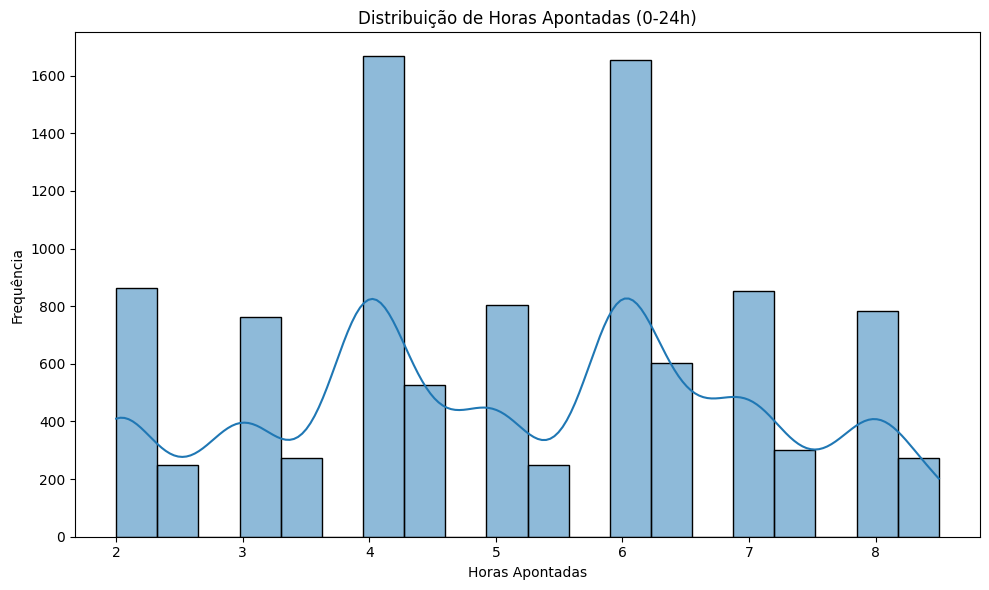

In [299]:
df_apontamentos = dfs['apontamentos'].copy()
df_apontamentos['horas_numeric'] = df_apontamentos['horas'].astype(str).str.replace(',', '.', regex=False)
df_apontamentos['horas_numeric'] = pd.to_numeric(df_apontamentos['horas_numeric'], errors='coerce')

# Filtrar valores válidos para o histograma (0 a 24 horas)
horas_validas = df_apontamentos['horas_numeric'].dropna()
horas_validas = horas_validas[(horas_validas >= 0) & (horas_validas <= 24)]

plt.figure(figsize=(10, 6))
sns.histplot(horas_validas, kde=True, bins=20)
plt.title('Distribuição de Horas Apontadas (0-24h)')
plt.xlabel('Horas Apontadas')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

#### 5.2.9.2 Top 10 Analistas por Total de Horas

/tmp/ipykernel_919/903318243.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_analistas_horas.index, y=top_analistas_horas.values, palette='cubehelix')


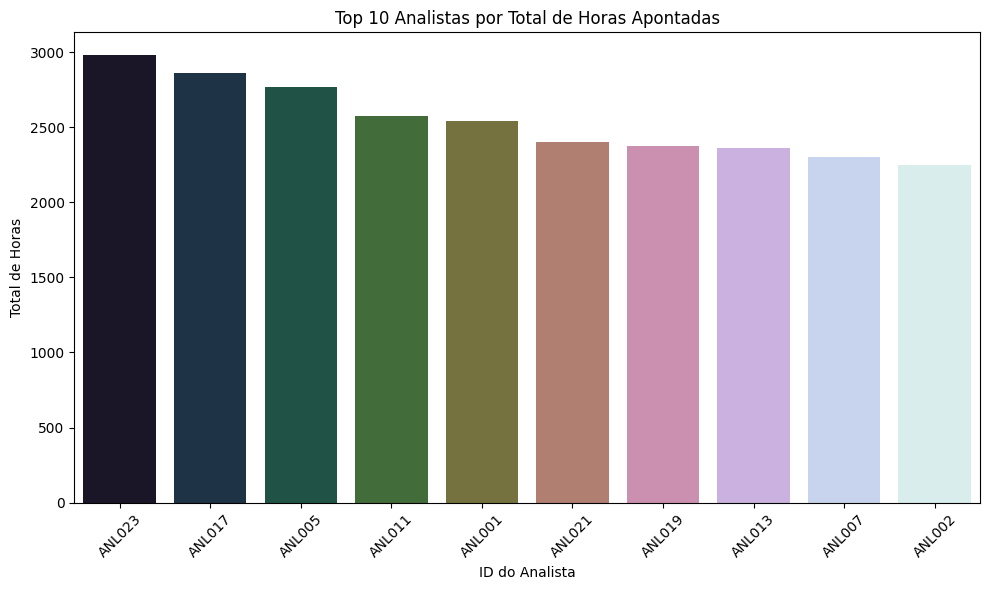

In [300]:
top_analistas_horas = df_apontamentos.groupby('analista_id')['horas_numeric'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_analistas_horas.index, y=top_analistas_horas.values, palette='cubehelix')
plt.title('Top 10 Analistas por Total de Horas Apontadas')
plt.xlabel('ID do Analista')
plt.ylabel('Total de Horas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 5.2.9.3 Top 10 Projetos por Total de Horas

/tmp/ipykernel_919/3524323205.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_projetos_horas.index, y=top_projetos_horas.values, palette='rocket')


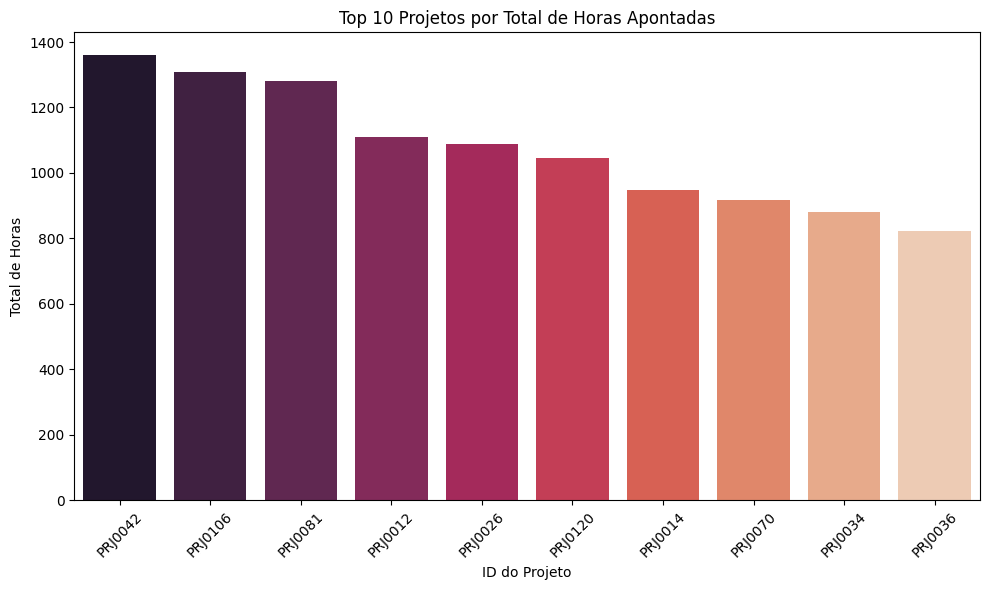

In [301]:
top_projetos_horas = df_apontamentos.groupby('projeto_id')['horas_numeric'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_projetos_horas.index, y=top_projetos_horas.values, palette='rocket')
plt.title('Top 10 Projetos por Total de Horas Apontadas')
plt.xlabel('ID do Projeto')
plt.ylabel('Total de Horas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.3 Diagnóstico - `dc_clientes.csv`

### 5.3.1 Estrutura

In [302]:
df_name = 'clientes'
try:
    df = dfs[df_name]
    print(f"**Iniciando diagnóstico para `{df_name}`...**\n")
    analyze_structure(df_name, df)
except KeyError:
    print(f"ERRO: DataFrame '{df_name}' não encontrado. Certifique-se de que a célula de carregamento de dados (célula 0d49ec36) foi executada e que o arquivo '{df_name}.csv' foi carregado corretamente.")
except Exception as e:
    print(f"Ocorreu um erro ao processar o DataFrame '{df_name}': {e}")

**Iniciando diagnóstico para `clientes`...**

  **Estrutura da tabela 'clientes'**
  - Dimensões do DataFrame (linhas, colunas):


(62, 7)

  - Nomes das colunas:


,0
0,cliente_id
1,cliente
2,setor
3,porte
4,cidade
5,uf
6,data_cadastro


### 5.3.2 Primeiras linhas

In [303]:
display_head(df_name, df)

  **Primeiras 10 linhas da tabela 'clientes'**


,cliente_id,cliente,setor,porte,cidade,uf,data_cadastro
0,CLI001,Umbu S.A.,NaN,Pequeno,Rio de Janeiro,Rio de Janeiro,2021-10-13
1,CLI002,Xingu S.A.,Indústria,Médio,Florianópolis,SC,2021-03-07
2,CLI003,Aurora S.A.,Saúde,Médio,Curitiba,PR,2021-02-24
3,CLI004,Rubi Ltda,Logística,Pequeno,Florianópolis,SC,2024-04-21
4,CLI005,Ipê S.A.,Logística,Pequeno,Belo Horizonte,MG,15/11/2021
5,CLI006,Granito Participações,Indústria,Pequeno,São Paulo,SP,06-jan-2023
6,CLI007,Coral Participações,Educação,Grande,Fortaleza,CE,02/03/2025
7,CLI008,Orion Holding,Logística,Pequeno,São Paulo,SP,2022-08-24
8,CLI009,Basalto Brasil,Energia,Médio,Fortaleza,CE,2024-12-13
9,CLI010,Cristal S.A.,EDUCAÇÃO,Grande,Curitiba,PR,2025-10-18


### 5.3.3 Tipos

In [304]:
analyze_dtypes(df_name, df)

  **Tipos de dados da tabela 'clientes'**
  - Informações detalhadas (`df.info()`):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   cliente_id     62 non-null     object
 1   cliente        62 non-null     object
 2   setor          57 non-null     object
 3   porte          62 non-null     object
 4   cidade         62 non-null     object
 5   uf             62 non-null     object
 6   data_cadastro  62 non-null     object
dtypes: object(7)
memory usage: 3.5+ KB
  - Tipos de dados das colunas (`df.dtypes`):


,0
cliente_id,object
cliente,object
setor,object
porte,object
cidade,object
uf,object
data_cadastro,object


### 5.3.4 Nulos

In [305]:
analyze_nulls(df_name, df)

  **Valores Nulos na tabela 'clientes'**
    Colunas com valores nulos (e suas contagens):


,0
setor,5


### 5.3.5 Duplicatas

In [306]:
analyze_duplicates(df_name, df, primary_keys_map)

  **Análise de Duplicatas na tabela 'clientes'**
    - Linhas duplicadas completas: 2
    - Duplicatas pela chave primária 'cliente_id': 2
      Registros duplicados pela chave 'cliente_id' (exemplos):


,cliente_id,cliente,setor,porte,cidade,uf,data_cadastro
3,CLI004,Rubi Ltda,Logística,Pequeno,Florianópolis,SC,2024-04-21
60,CLI004,Rubi Ltda,Logística,Pequeno,Florianópolis,SC,2024-04-21
27,CLI028,Rubi Holding,SETOR PÚBLICO,Pequeno,Rio de Janeiro,RJ,02/09/2021
61,CLI028,Rubi Holding,SETOR PÚBLICO,Pequeno,Rio de Janeiro,RJ,02/09/2021


### 5.3.6 Categorias e textos

In [307]:
analyze_categorical_text(df_name, df, primary_keys_map)

  **Análise de Colunas Categóricas/Texto na tabela 'clientes'**
    - Coluna 'cliente':
      60 valores únicos (mostrando os 5 primeiros):


,0
0,Umbu S.A.
1,Xingu S.A.
2,Aurora S.A.
3,Rubi Ltda
4,Ipê S.A.


      AVISO: Existem valores com espaços no início ou fim. Exemplo: 'Umbu S.A.  '
    - Coluna 'setor':
      Valores únicos (18):


,0
0,Agronegócio
1,Saúde
2,Serviços Financeiros
3,Agronegócio
4,EDUCAÇÃO
5,ENERGIA
6,Educação
7,Energia
8,Indústria
9,Logística


      AVISO: Existem valores com espaços no início ou fim. Exemplo: ' Agronegócio '
    - Coluna 'porte':
      Valores únicos (3):


...

      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'uf':
      Valores únicos (19):


,0
0,BA
1,Brasília
2,CE
3,Curitiba
4,DF
5,MG
6,PE
7,PR
8,RJ
9,RS


      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'data_cadastro':
      60 valores únicos (mostrando os 5 primeiros):


,0
0,2021-10-13
1,2021-03-07
2,2021-02-24
3,2024-04-21
4,15/11/2021


      Não foram encontrados valores com espaços no início ou fim.


### 5.3.7 Datas

In [308]:
analyze_dates(df_name, df, date_columns_map)

  **Análise de Colunas de Data na tabela 'clientes'**
    - Coluna 'data_cadastro':
      Total de valores: 62
      Valores nulos: 0
      Padrões de representação encontrados (e exemplos):
        - '%Y-%m-%d': 36 ocorrências. Exemplos:


,0
0,2021-10-13
1,2021-03-07
2,2021-02-24
3,2024-04-21
4,2022-08-24


        - '%d/%m/%Y': 13 ocorrências. Exemplos:


,0
0,15/11/2021
1,02/03/2025
2,01/07/2022
3,08/03/2024
4,28/05/2023


        - 'DD-mmm-YYYY (Meses PT-BR)': 8 ocorrências. Exemplos:


...

        - '%m/%d/%Y': 3 ocorrências. Exemplos:


,0
0,05/26/2021
1,08/28/2024
2,01/18/2024


      Datas ambíguas (DD/MM/YYYY ou MM/DD/YYYY):
        8 valores ambíguos. Exemplos:


,0
0,02/03/2025
1,01/07/2022
2,08/03/2024
3,11/10/2021
4,02/09/2021


      Datas claramente inválidas ou impossíveis:
        Nenhuma data claramente inválida encontrada.


### 5.3.8 Resumo do `dc_clientes`

In [309]:
print_summary(df_name)


  --- Resumo do Diagnóstico para: CLIENTES ---
  (Revise as saídas acima para detalhes dos problemas encontrados.)


#### 5.3.8.1 Distribuição de Clientes por Setor

/tmp/ipykernel_919/2064201542.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clientes, y='setor_clean', palette='viridis', order=df_clientes['setor_clean'].value_counts().index)


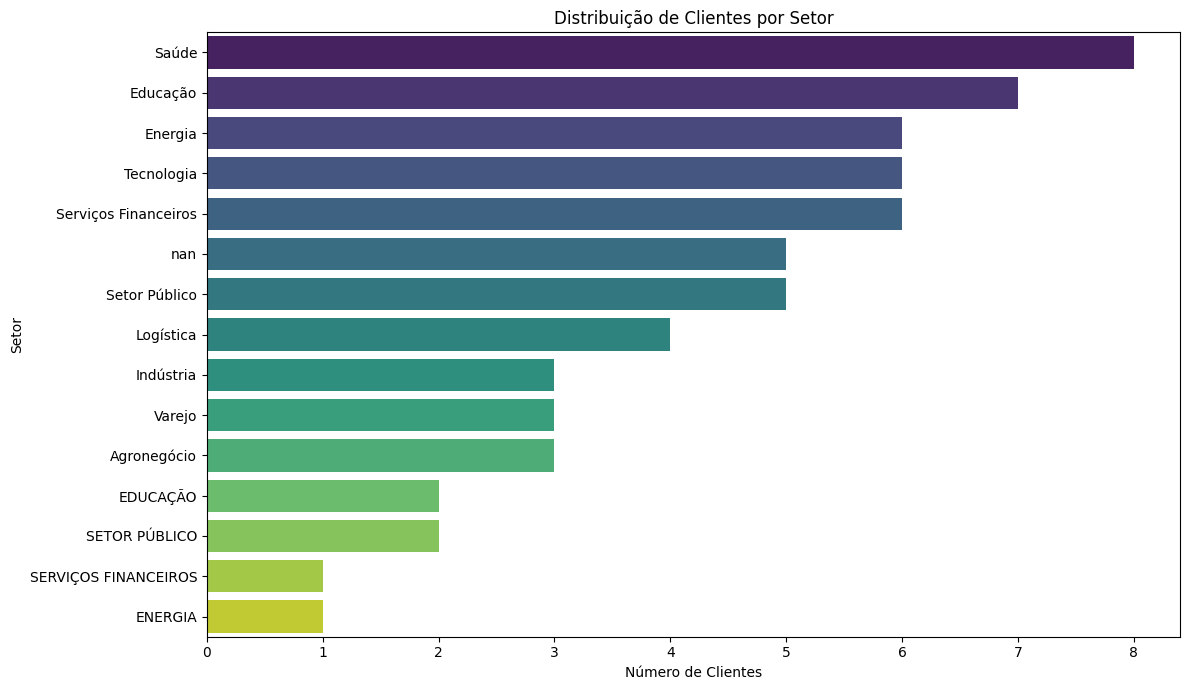

In [310]:
try:
    df_clientes = dfs['clientes'].copy()
    # Limpar espaços em branco para uma contagem mais precisa
    df_clientes['setor_clean'] = df_clientes['setor'].astype(str).str.strip()

    plt.figure(figsize=(12, 7))
    sns.countplot(data=df_clientes, y='setor_clean', palette='viridis', order=df_clientes['setor_clean'].value_counts().index)
    plt.title('Distribuição de Clientes por Setor')
    plt.xlabel('Número de Clientes')
    plt.ylabel('Setor')
    plt.tight_layout()
    plt.show()
except KeyError:
    print("ERRO: DataFrame 'clientes' não encontrado para gerar o gráfico.")
except Exception as e:
    print(f"Ocorreu um erro ao gerar o gráfico de Clientes por Setor: {e}")

#### 5.3.8.2 Distribuição de Clientes por Porte

/tmp/ipykernel_919/3844153470.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clientes, x='porte_clean', palette='plasma', order=['Pequeno', 'Médio', 'Grande'])


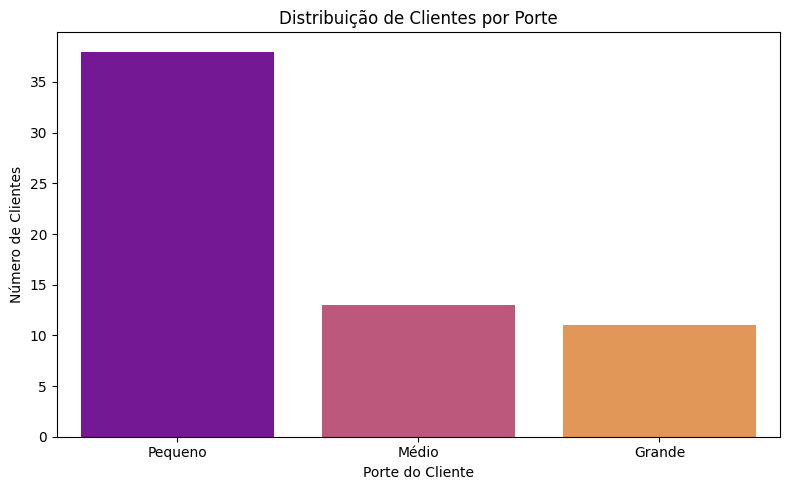

In [311]:
try:
    if 'df_clientes' in locals():
        df_clientes['porte_clean'] = df_clientes['porte'].astype(str).str.strip()

        plt.figure(figsize=(8, 5))
        sns.countplot(data=df_clientes, x='porte_clean', palette='plasma', order=['Pequeno', 'Médio', 'Grande'])
        plt.title('Distribuição de Clientes por Porte')
        plt.xlabel('Porte do Cliente')
        plt.ylabel('Número de Clientes')
        plt.tight_layout()
        plt.show()
    else:
        print("AVISO: 'df_clientes' não está definido. Execute a célula anterior ('58ea15ce') primeiro.")
except Exception as e:
    print(f"Ocorreu um erro ao gerar o gráfico de Clientes por Porte: {e}")

## 5.4 Diagnóstico - `dc_analistas.csv`

### 5.4.1 Estrutura

In [312]:
df_name = 'analistas'
try:
    df = dfs[df_name]
    print(f"**Iniciando diagnóstico para `{df_name}`...**\n")
    analyze_structure(df_name, df)
except KeyError:
    print(f"ERRO: DataFrame '{df_name}' não encontrado. Certifique-se de que a célula de carregamento de dados (célula 0d49ec36) foi executada e que o arquivo '{df_name}.csv' foi carregado corretamente.")
except Exception as e:
    print(f"Ocorreu um erro ao processar o DataFrame '{df_name}': {e}")

**Iniciando diagnóstico para `analistas`...**

  **Estrutura da tabela 'analistas'**
  - Dimensões do DataFrame (linhas, colunas):


(24, 6)

  - Nomes das colunas:


,0
0,analista_id
1,analista
2,squad
3,senioridade
4,custo_hora
5,data_admissao


### 5.4.2 Primeiras linhas

In [313]:
display_head(df_name, df)

  **Primeiras 10 linhas da tabela 'analistas'**


,analista_id,analista,squad,senioridade,custo_hora,data_admissao
0,ANL001,Ana Barbosa,ALPHA,Senior,"150,00",2021-12-07
1,ANL002,Bruno Ipiranga,Bravo,Pleno,95.00,2021-08-30
2,ANL003,Carla Esteves,Charlie,Junior,55.00,2024-12-26
3,ANL004,Diego Freitas,Delta,Especialista,210.00,2025-07-28
4,ANL005,Elisa Werneck,Echo,Pleno,95.00,24/10/2023
5,ANL006,Felipe Duarte,Foxtrot,Pleno,"95,00",02-nov-2021
6,ANL007,Gabriela Werneck,Alpha,Especialista,210.00,04/02/2022
7,ANL008,Henrique Lopes,Bravo,Pleno,95.00,2024-09-05
8,ANL009,Isabela Nunes,CHARLIE,Pleno,95.00,2022-02-17
9,ANL010,João Lopes,Delta,Junior,55.00,2025-11-17


### 5.4.3 Tipos

In [314]:
analyze_dtypes(df_name, df)

  **Tipos de dados da tabela 'analistas'**
  - Informações detalhadas (`df.info()`):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   analista_id    24 non-null     object
 1   analista       24 non-null     object
 2   squad          24 non-null     object
 3   senioridade    24 non-null     object
 4   custo_hora     24 non-null     object
 5   data_admissao  24 non-null     object
dtypes: object(6)
memory usage: 1.3+ KB
  - Tipos de dados das colunas (`df.dtypes`):


,0
analista_id,object
analista,object
squad,object
senioridade,object
custo_hora,object
data_admissao,object


### 5.4.4 Nulos

In [315]:
analyze_nulls(df_name, df)

  **Valores Nulos na tabela 'analistas'**
    Não há valores nulos em nenhuma coluna.


### 5.4.5 Duplicatas

In [316]:
analyze_duplicates(df_name, df, primary_keys_map)

  **Análise de Duplicatas na tabela 'analistas'**
    - Linhas duplicadas completas: 0
    - Duplicatas pela chave primária 'analista_id': 0


### 5.4.6 Categorias e textos

In [317]:
analyze_categorical_text(df_name, df, primary_keys_map)

  **Análise de Colunas Categóricas/Texto na tabela 'analistas'**
    - Coluna 'analista':
      Valores únicos (24):


,0
0,Ana Barbosa
1,Bruno Ipiranga
2,Carla Esteves
3,Diego Freitas
4,Elisa Werneck
5,Felipe Duarte
6,Gabriela Werneck
7,Henrique Lopes
8,Isabela Nunes
9,João Lopes


      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'squad':
      Valores únicos (9):


,0
0,ALPHA
1,Alpha
2,Bravo
3,CHARLIE
4,Charlie
5,Delta
6,ECHO
7,Echo
8,Foxtrot


      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'senioridade':
      Valores únicos (4):


...

      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'custo_hora':
      Valores únicos (7):


,0
0,"150,00"
1,150.00
2,"210,00"
3,210.00
4,55.00
5,"95,00"
6,95.00


      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'data_admissao':
      Valores únicos (24):


,0
0,02-nov-2021
1,04/02/2022
2,04/13/2022
3,08/19/2021
4,11-set-2023
5,17/12/2025
6,2021-08-30
7,2021-12-07
8,2022-02-17
9,2022-04-29


      Não foram encontrados valores com espaços no início ou fim.


### 5.4.7 Datas

In [318]:
analyze_dates(df_name, df, date_columns_map)

  **Análise de Colunas de Data na tabela 'analistas'**
    - Coluna 'data_admissao':
      Total de valores: 24
      Valores nulos: 0
      Padrões de representação encontrados (e exemplos):
        - '%Y-%m-%d': 15 ocorrências. Exemplos:


,0
0,2021-12-07
1,2021-08-30
2,2024-12-26
3,2025-07-28
4,2024-09-05


        - '%d/%m/%Y': 4 ocorrências. Exemplos:


,0
0,24/10/2023
1,04/02/2022
2,25/02/2025
3,17/12/2025


        - 'DD-mmm-YYYY (Meses PT-BR)': 3 ocorrências. Exemplos:


...

        - '%m/%d/%Y': 2 ocorrências. Exemplos:


,0
0,04/13/2022
1,08/19/2021


      Datas ambíguas (DD/MM/YYYY ou MM/DD/YYYY):
        1 valores ambíguos. Exemplos:


,0
0,04/02/2022


      Datas claramente inválidas ou impossíveis:
        Nenhuma data claramente inválida encontrada.


### 5.4.8 Análise de `custo_hora`

In [319]:
if 'custo_hora' in df.columns:
    analyze_costo_hora(df)
else:
    print("  Columna 'custo_hora' não encontrada.")

  **Análise da coluna 'custo_hora'**
    - Estatísticas descritivas:


,custo_hora
count,19.000000
mean,113.157895
std,60.969267
min,55.000000
25%,55.000000
50%,95.000000
75%,150.000000
max,210.000000


### 5.4.9 Resumo do `dc_analistas`

In [320]:
print_summary(df_name)


  --- Resumo do Diagnóstico para: ANALISTAS ---
  (Revise as saídas acima para detalhes dos problemas encontrados.)


#### 5.4.9.1 Distribuição de Analistas por Squad

/tmp/ipykernel_919/2223941256.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analistas, y='squad', palette='viridis', order=df_analistas['squad'].value_counts().index)


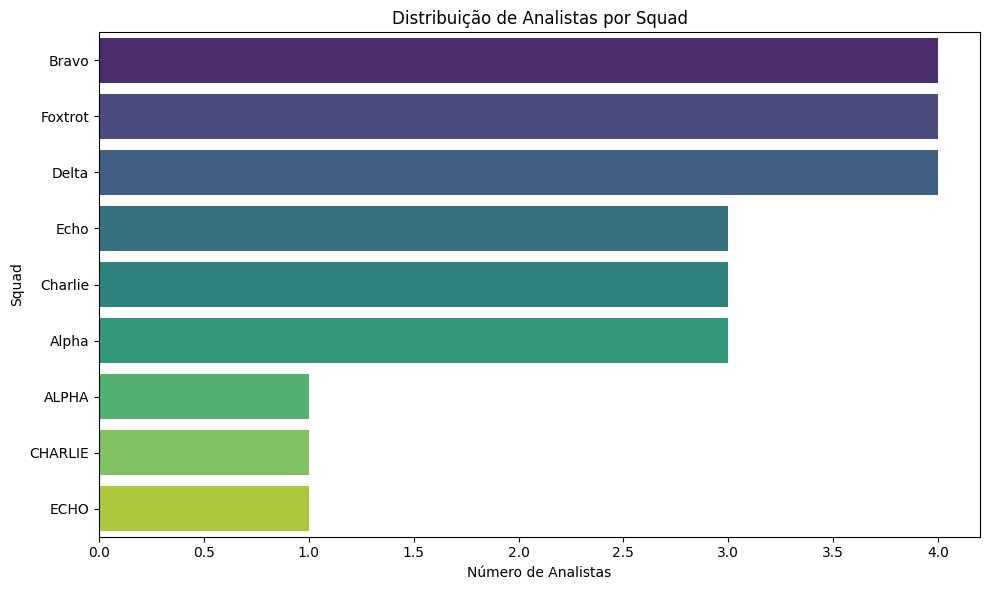

In [321]:
try:
    df_analistas = dfs['analistas'].copy()
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_analistas, y='squad', palette='viridis', order=df_analistas['squad'].value_counts().index)
    plt.title('Distribuição de Analistas por Squad')
    plt.xlabel('Número de Analistas')
    plt.ylabel('Squad')
    plt.tight_layout()
    plt.show()
except KeyError:
    print("ERRO: DataFrame 'analistas' não encontrado para gerar o gráfico.")
except Exception as e:
    print(f"Ocorreu um erro ao gerar o gráfico de Analistas por Squad: {e}")

#### 5.4.9.2 Distribuição de Analistas por Senioridade

/tmp/ipykernel_919/1217470013.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analistas, x='senioridade', palette='mako', order=df_analistas['senioridade'].value_counts().index)


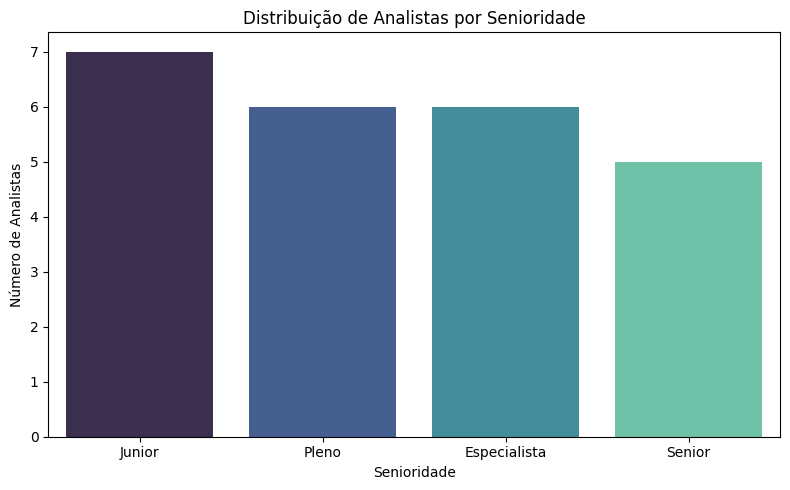

In [322]:
try:
    if 'df_analistas' in locals():
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df_analistas, x='senioridade', palette='mako', order=df_analistas['senioridade'].value_counts().index)
        plt.title('Distribuição de Analistas por Senioridade')
        plt.xlabel('Senioridade')
        plt.ylabel('Número de Analistas')
        plt.tight_layout()
        plt.show()
    else:
        print("AVISO: 'df_analistas' não está definido. Execute a célula anterior ('661f6d2e') primeiro.")
except Exception as e:
    print(f"Ocorreu um erro ao gerar o gráfico de Analistas por Senioridade: {e}")

#### 5.4.9.3 Distribuição de Custo por Hora dos Analistas

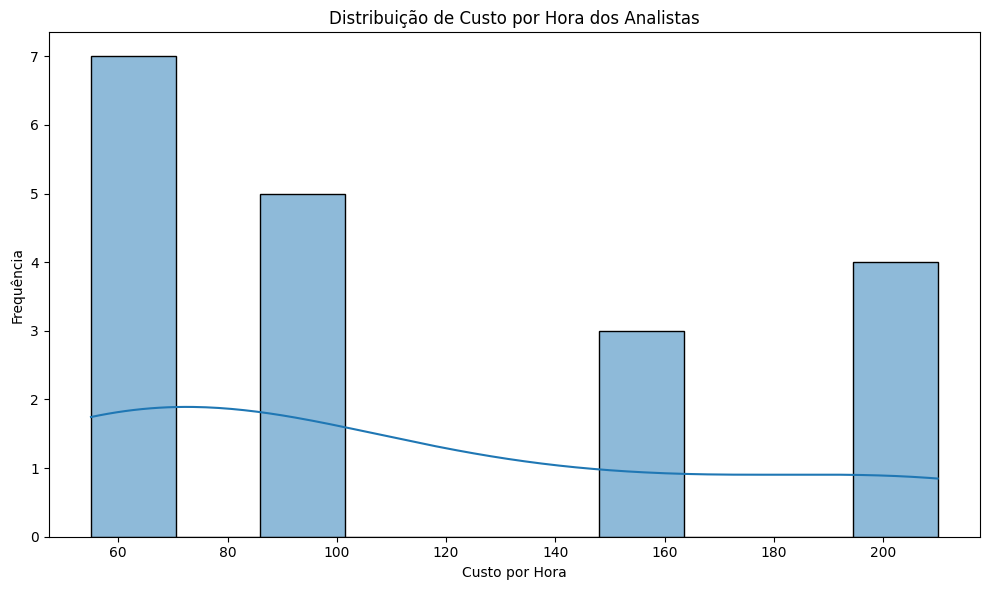

In [323]:
try:
    if 'df_analistas' in locals():
        df_analistas['custo_hora_numeric'] = pd.to_numeric(df_analistas['custo_hora'], errors='coerce')

        plt.figure(figsize=(10, 6))
        sns.histplot(df_analistas['custo_hora_numeric'].dropna(), kde=True, bins=10)
        plt.title('Distribuição de Custo por Hora dos Analistas')
        plt.xlabel('Custo por Hora')
        plt.ylabel('Frequência')
        plt.tight_layout()
        plt.show()
    else:
        print("AVISO: 'df_analistas' não está definido. Execute as células anteriores que o inicializam.")
except Exception as e:
    print(f"Ocorreu um erro ao gerar o gráfico de Custo por Hora dos Analistas: {e}")

## 5.5 Diagnóstico - `dc_satisfacao.csv`

### 5.5.1 Estrutura

In [324]:
df_name = 'satisfacao'
try:
    df = dfs[df_name]
    print(f"**Iniciando diagnóstico para `{df_name}`...**\n")
    analyze_structure(df_name, df)
except KeyError:
    print(f"ERRO: DataFrame '{df_name}' não encontrado. Certifique-se de que a célula de carregamento de dados (célula 0d49ec36) foi executada e que o arquivo '{df_name}.csv' foi carregado corretamente.")
except Exception as e:
    print(f"Ocorreu um erro ao processar o DataFrame '{df_name}': {e}")

**Iniciando diagnóstico para `satisfacao`...**

  **Estrutura da tabela 'satisfacao'**
  - Dimensões do DataFrame (linhas, colunas):


(103, 5)

  - Nomes das colunas:


,0
0,pesquisa_id
1,projeto_id
2,data_pesquisa
3,nota_nps
4,comentario


### 5.5.2 Primeiras linhas

In [325]:
display_head(df_name, df)

  **Primeiras 10 linhas da tabela 'satisfacao'**


,pesquisa_id,projeto_id,data_pesquisa,nota_nps,comentario
0,PSQ0001,PRJ0001,2024-05-27,NaN,"Resultado ok, prazo apertado."
1,PSQ0002,PRJ0003,2025-10-20,10.0,Documentação impecável.
2,PSQ0003,PRJ0004,2024-05-08,9.0,Documentação impecável.
3,PSQ0004,PRJ0005,2025-03-27,7.0,"Bom projeto, comunicação pode melhorar."
4,PSQ0005,PRJ0006,17/07/2025,6.0,Suporte demorou a responder.
5,PSQ0006,PRJ0010,06-nov-2024,9.0,Ganhamos agilidade nas decisões.
6,PSQ0007,PRJ0011,09/15/2025,7.0,"Bom projeto, comunicação pode melhorar."
7,PSQ0008,PRJ0013,2025-01-21,8.0,Atendeu ao combinado.
8,PSQ0009,PRJ0014,2024-11-27,6.0,Precisamos refazer parte do painel.
9,PSQ0010,PRJ0015,2025-12-29,8.0,"Resultado ok, prazo apertado."


### 5.5.3 Tipos

In [326]:
analyze_dtypes(df_name, df)

  **Tipos de dados da tabela 'satisfacao'**
  - Informações detalhadas (`df.info()`):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pesquisa_id    103 non-null    object 
 1   projeto_id     103 non-null    object 
 2   data_pesquisa  103 non-null    object 
 3   nota_nps       95 non-null     float64
 4   comentario     103 non-null    object 
dtypes: float64(1), object(4)
memory usage: 4.2+ KB
  - Tipos de dados das colunas (`df.dtypes`):


,0
pesquisa_id,object
projeto_id,object
data_pesquisa,object
nota_nps,float64
comentario,object


In [327]:
horas_columns_count = 0
dfs_with_horas = []

for df_name, df in dfs.items():
    if 'horas' in df.columns:
        horas_columns_count += 1
        dfs_with_horas.append(df_name)

print(f"Total de colunas 'horas' encontradas em {horas_columns_count} DataFrames.")
if horas_columns_count > 0:
    print(f"DataFrames com a coluna 'horas': {', '.join(dfs_with_horas)}")
else:
    print("Nenhum DataFrame possui uma coluna chamada 'horas'.")

Total de colunas 'horas' encontradas em 1 DataFrames.
DataFrames com a coluna 'horas': apontamentos


### 5.5.4 Nulos

In [328]:
df_name = 'satisfacao'
df = dfs[df_name]
analyze_nulls(df_name, df)

  **Valores Nulos na tabela 'satisfacao'**
    Colunas com valores nulos (e suas contagens):


,0
nota_nps,8


In [329]:
### 5.6.1 Visualização de Linhas Duplicadas em Todos os DataFrames

### 5.5.5 Duplicatas

In [330]:
analyze_duplicates(df_name, df, primary_keys_map)

  **Análise de Duplicatas na tabela 'satisfacao'**
    - Linhas duplicadas completas: 0
    - Duplicatas pela chave primária 'pesquisa_id': 0


### 5.5.6 Categorias e textos

In [331]:
analyze_categorical_text(df_name, df, primary_keys_map)

  **Análise de Colunas Categóricas/Texto na tabela 'satisfacao'**
    - Coluna 'projeto_id':
      103 valores únicos (mostrando os 5 primeiros):


,0
0,PRJ0001
1,PRJ0003
2,PRJ0004
3,PRJ0005
4,PRJ0006


      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'data_pesquisa':
      100 valores únicos (mostrando os 5 primeiros):


,0
0,2024-05-27
1,2025-10-20
2,2024-05-08
3,2025-03-27
4,17/07/2025


      Não foram encontrados valores com espaços no início ou fim.
    - Coluna 'comentario':
      Valores únicos (10):


,0
0,Atendeu ao combinado.
1,Atraso significativo na entrega.
2,"Bom projeto, comunicação pode melhorar."
3,Documentação impecável.
4,Entrega no prazo e time muito atencioso.
5,Ganhamos agilidade nas decisões.
6,O painel virou rotina da diretoria.
7,Precisamos refazer parte do painel.
8,"Resultado ok, prazo apertado."
9,Suporte demorou a responder.


      Não foram encontrados valores com espaços no início ou fim.


### 5.5.7 Datas

In [332]:
analyze_dates(df_name, df, date_columns_map)

  **Análise de Colunas de Data na tabela 'satisfacao'**
    - Coluna 'data_pesquisa':
      Total de valores: 103
      Valores nulos: 0
      Padrões de representação encontrados (e exemplos):
        - '%Y-%m-%d': 57 ocorrências. Exemplos:


,0
0,2024-05-27
1,2025-10-20
2,2024-05-08
3,2025-03-27
4,2025-01-21


        - '%d/%m/%Y': 20 ocorrências. Exemplos:


,0
0,17/07/2025
1,26/03/2025
2,03/03/2025
3,30/04/2025
4,11/06/2024


        - 'DD-mmm-YYYY (Meses PT-BR)': 14 ocorrências. Exemplos:


...

        - '%m/%d/%Y': 9 ocorrências. Exemplos:


,0
0,09/15/2025
1,04/21/2025
2,12/30/2024
3,03/24/2025
4,01/14/2026


      Datas ambíguas (DD/MM/YYYY ou MM/DD/YYYY):
        11 valores ambíguos. Exemplos:


,0
0,03/03/2025
1,11/06/2024
2,04/08/2024
3,11/04/2024
4,03/06/2026


      Datas claramente inválidas ou impossíveis:
        Nenhuma data claramente inválida encontrada.


### 5.5.8 Análise de `nota_nps`

In [333]:
if 'nota_nps' in df.columns:
    analyze_nota_nps(df)
else:
    print("  Columna 'nota_nps' não encontrada.")

  **Análise da coluna 'nota_nps'**
    - Estatísticas descritivas:


,nota_nps
count,95.000000
mean,8.421053
std,1.601721
min,3.000000
25%,8.000000
50%,9.000000
75%,10.000000
max,10.000000


### 5.5.9 Resumo do `dc_satisfacao`

In [334]:
print_summary(df_name)


  --- Resumo do Diagnóstico para: SATISFACAO ---
  (Revise as saídas acima para detalhes dos problemas encontrados.)


#### 5.5.9.1 Distribuição de Notas NPS

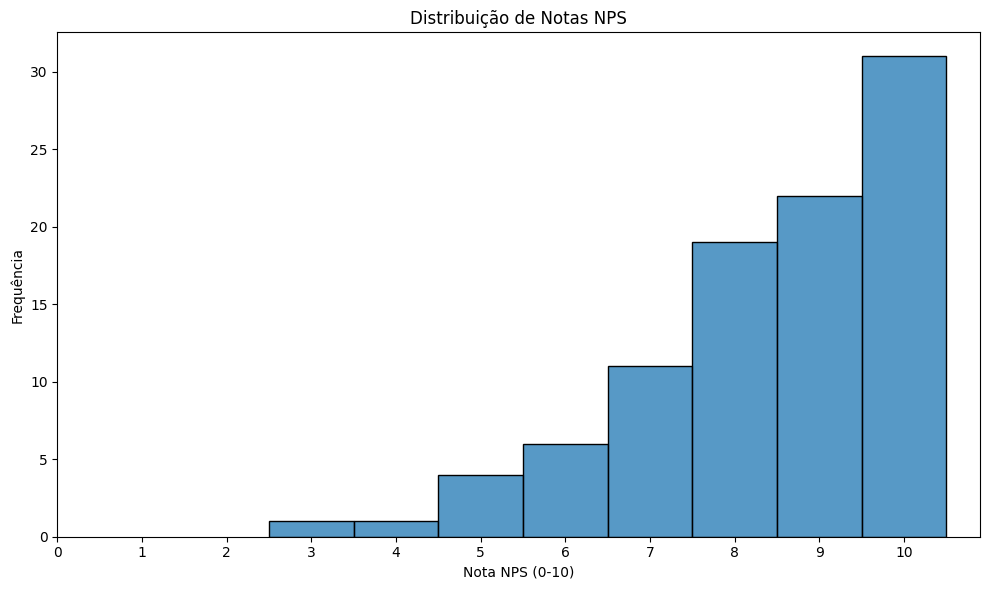

In [335]:
try:
    df_satisfacao = dfs['satisfacao'].copy()

    plt.figure(figsize=(10, 6))
    sns.histplot(df_satisfacao['nota_nps'].dropna(), kde=False, bins=11, discrete=True)
    plt.title('Distribuição de Notas NPS')
    plt.xlabel('Nota NPS (0-10)')
    plt.ylabel('Frequência')
    plt.xticks(range(0, 11))
    plt.tight_layout()
    plt.show()
except KeyError:
    print("ERRO: DataFrame 'satisfacao' não encontrado para gerar o gráfico.")
except Exception as e:
    print(f"Ocorreu um erro ao gerar o gráfico de Distribuição de Notas NPS: {e}")

#### 5.5.9.2 Distribuição de Categorias NPS

/tmp/ipykernel_919/2319863892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_satisfacao, x='nps_categoria', palette='coolwarm', order=['Detrator', 'Passivo', 'Promotor', 'Não Avaliado'])


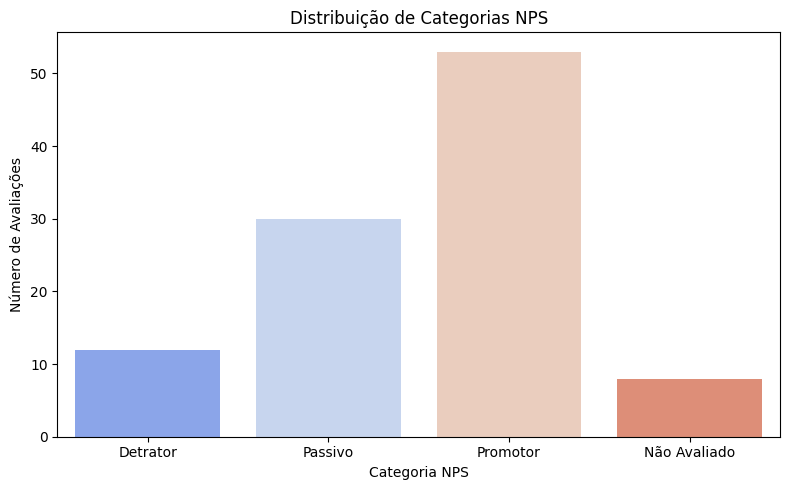

In [336]:
try:
    if 'df_satisfacao' in locals():
        def categorize_nps(score):
            if pd.isna(score): return 'Não Avaliado'
            if score >= 9: return 'Promotor'
            if score >= 7: return 'Passivo'
            return 'Detrator'

        df_satisfacao['nps_categoria'] = df_satisfacao['nota_nps'].apply(categorize_nps)

        plt.figure(figsize=(8, 5))
        sns.countplot(data=df_satisfacao, x='nps_categoria', palette='coolwarm', order=['Detrator', 'Passivo', 'Promotor', 'Não Avaliado'])
        plt.title('Distribuição de Categorias NPS')
        plt.xlabel('Categoria NPS')
        plt.ylabel('Número de Avaliações')
        plt.tight_layout()
        plt.show()
    else:
        print("AVISO: 'df_satisfacao' não está definido. Execute a célula anterior ('5ec27448') primeiro.")
except Exception as e:
    print(f"Ocorreu um erro ao gerar o gráfico de Categorias NPS: {e}")

## 5.6 Diagnósticos Gerais

### 5.6.1 Contagem de Colunas 'horas' em todos os DataFrames

In [337]:
horas_columns_count = 0
dfs_with_horas = []

for df_name, df in dfs.items():
    if 'horas' in df.columns:
        horas_columns_count += 1
        dfs_with_horas.append(df_name)

print(f"Total de colunas 'horas' encontradas em {horas_columns_count} DataFrames.")
if horas_columns_count > 0:
    print(f"DataFrames com a coluna 'horas': {', '.join(dfs_with_horas)}")
else:
    print("Nenhum DataFrame possui uma coluna chamada 'horas'.")

Total de colunas 'horas' encontradas em 1 DataFrames.
DataFrames com a coluna 'horas': apontamentos


### 5.6.2 Visualização de Linhas Duplicadas em Todos os DataFrames

In [338]:
print("\n**Exibindo Linhas Duplicadas em Todos os DataFrames:**\n")

for df_name, df in dfs.items():
    # Certifica-se de que a coluna PK está sendo usada corretamente para ordenação, se existir
    pk_col = primary_keys_map.get(df_name)
    if pk_col and pk_col in df.columns:
        sort_cols = [pk_col] + [col for col in df.columns if col != pk_col]
    else:
        sort_cols = df.columns.tolist()

    full_duplicates = df[df.duplicated(keep=False)].sort_values(by=sort_cols)
    if not full_duplicates.empty:
        print(f"**--- Duplicatas na tabela '{df_name}' ({len(full_duplicates)} linhas) ---**")
        display(full_duplicates)
        print("\n")
    else:
        print(f"--- Nenhuma linha duplicada completa encontrada na tabela '{df_name}' ---")
        print("\n")


**Exibindo Linhas Duplicadas em Todos os DataFrames:**

**--- Duplicatas na tabela 'apontamentos' (160 linhas) ---**


,apontamento_id,projeto_id,analista_id,data,horas,atividade
1826,APT000001,PRJ0001,ANL004,2024-04-24,2,COLETA
4603,APT000001,PRJ0001,ANL004,2024-04-24,2,COLETA
3391,APT000098,PRJ0003,ANL021,07/14/2025,4,Dashboard
4046,APT000098,PRJ0003,ANL021,07/14/2025,4,Dashboard
3790,APT000195,PRJ0004,ANL011,03-abr-2024,4,Testes
...,...,...,...,...,...,...
2399,APT007470,PRJ0106,ANL003,2026-06-25,6.5,Testes
1257,APT007567,PRJ0106,ANL009,06/15/2026,6,Apresentação
5153,APT007567,PRJ0106,ANL009,06/15/2026,6,Apresentação
5478,APT007664,PRJ0109,ANL013,10-jun-2026,4,ETL




**--- Duplicatas na tabela 'projetos' (2 linhas) ---**


,projeto_id,cliente_id,nome_projeto,tipo_servico,squad,status,data_inicio,data_fim_prevista,data_fim_real,horas_vendidas,valor_contrato
9,PRJ0010,CLI001,Modelo Preditivo - Umbu,Modelo Preditivo,Alpha,Concluído,2024-07-08,22/10/2024,10/21/2024,578,98986.73
140,PRJ0010,CLI001,Modelo Preditivo - Umbu,Modelo Preditivo,Alpha,Concluído,2024-07-08,22/10/2024,10/21/2024,578,98986.73




**--- Duplicatas na tabela 'clientes' (4 linhas) ---**


,cliente_id,cliente,setor,porte,cidade,uf,data_cadastro
3,CLI004,Rubi Ltda,Logística,Pequeno,Florianópolis,SC,2024-04-21
60,CLI004,Rubi Ltda,Logística,Pequeno,Florianópolis,SC,2024-04-21
27,CLI028,Rubi Holding,SETOR PÚBLICO,Pequeno,Rio de Janeiro,RJ,02/09/2021
61,CLI028,Rubi Holding,SETOR PÚBLICO,Pequeno,Rio de Janeiro,RJ,02/09/2021




--- Nenhuma linha duplicada completa encontrada na tabela 'analistas' ---


--- Nenhuma linha duplicada completa encontrada na tabela 'satisfacao' ---




## 5.7. VALIDAÇÃO DOS RELACIONAMENTOS

In [339]:
print(f"\n{'='*50}\n--- Verificações de Consistência Entre Arquivos ---\n{'='*50}")

# 1. Verificar se todo `projeto_id` de `dc_apontamentos` existe em `dc_projetos`
print("\nVerificando `projeto_id` de `apontamentos` em `projetos`:")
check_foreign_key('apontamentos', 'projeto_id', 'projetos', 'projeto_id', dfs)

# 2. Verificar se todo `cliente_id` de `dc_projetos` existe em `dc_clientes`
print("\nVerificando `cliente_id` de `projetos` em `clientes`:")
check_foreign_key('projetos', 'cliente_id', 'clientes', 'cliente_id', dfs)

# 3. Verificar se todo `analista_id` de `dc_apontamentos` existe em `dc_analistas`
print("\nVerificando `analista_id` de `apontamentos` em `analistas`:")
check_foreign_key('apontamentos', 'analista_id', 'analistas', 'analista_id', dfs)

# 4. Verificar se todo `projeto_id` de `dc_satisfacao` existe em `dc_projetos`
print("\nVerificando `projeto_id` de `satisfacao` em `projetos`:")
check_foreign_key('satisfacao', 'projeto_id', 'projetos', 'projeto_id', dfs)

print(f"\n{'='*50}\n--- Fim das Verificações de Consistência ---\n{'='*50}\n")


--- Verificações de Consistência Entre Arquivos ---

Verificando `projeto_id` de `apontamentos` em `projetos`:
  Todos os 'projeto_id' em `apontamentos` existem em `projetos`.

Verificando `cliente_id` de `projetos` em `clientes`:
  Todos os 'cliente_id' em `projetos` existem em `clientes`.

Verificando `analista_id` de `apontamentos` em `analistas`:
  Todos os 'analista_id' em `apontamentos` existem em `analistas`.

Verificando `projeto_id` de `satisfacao` em `projetos`:
  Todos os 'projeto_id' em `satisfacao` existem em `projetos`.

--- Fim das Verificações de Consistência ---



# 7. LIMPEZA DOS DADOS

## 7.1 Limpeza - `dc_projetos.csv`

## 7.2 Limpeza - `dc_apontamentos.csv`

## 7.3 Limpeza - `dc_clientes.csv`

## 7.4 Limpeza - `dc_analistas.csv`

## 7.5 Limpeza - `dc_satisfacao.csv`